In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import subprocess

import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap

from scipy import stats
from sklearn.cluster import *
from sklearn.decomposition import PCA
from sklearn.preprocessing import *
from sklearn.metrics import *

def set_font_size(ax, font_size):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(font_size)

## Temporal analysis

In [3]:
rank_nofilter = pd.read_csv('results/ft/ranking/ft_ranking.csv')
rank_nofilter

,contract_id,contract_address,count
0,12071,dac17f958d2ee523a2206206994597c13d831ec7,149408698
1,13532,c02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,104183120
2,65331,a0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,42601224
3,124573,6b175474e89094c44da98b954eedeac495271d0f,14387573
4,6423,514910771af9ca656af840dff83e8264ecf986ca,11388177
...,...,...,...
386610,137211,4bee60b12f40def986f8d22b261c3d30178d1945,1
386611,380378,c1e5220fb60dd718503357343d43f31dfd87d8ff,1
386612,88711,42d62d463d88bd29cc2fedcc6f1e737ef122e9e4,1
386613,315509,fa9c964a01e5def0b220c125ed2c8ac420c44e39,1


In [80]:
rank_nofilter = pd.read_csv('results/ft/ranking/ft_ranking_nofilter.csv', header=None, names=['contractId', 'numTransfer'])
rank_nofilter

,contractId,numTransfer
0,148,1
1,463,2
2,471,1
3,496,1
4,833,1
...,...,...
386610,386099,23
386611,386141,1
386612,386226,3
386613,386412,19


In [99]:
data = rank_nofilter.numTransfer.value_counts()
data = data.reindex(np.arange(1, np.max(data.index)+1), fill_value=0)
data

numTransfer
1            76796
2            36590
3            22794
4            52800
5            12729
             ...  
149408694        0
149408695        0
149408696        0
149408697        0
149408698        1
Name: count, Length: 149408698, dtype: int64

numTransfer
1             76796
2            113386
3            136180
4            188980
5            201709
              ...  
149408694    386614
149408695    386614
149408696    386614
149408697    386614
149408698    386615
Name: count, Length: 149408698, dtype: int64

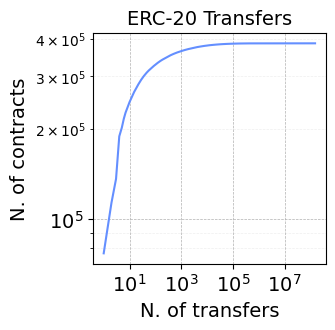

In [103]:
x = np.cumsum(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of contracts')
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(x.index, x.values, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
set_font_size(ax, 14)
plt.show()

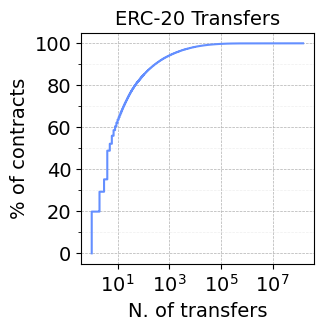

In [45]:
data = rank_nofilter.numTransfer
sorted_data = np.sort(data)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('% of contracts')
ax.set_xscale('log')
#ax.set_yscale('log')
#ax.step(sorted_data, (np.arange(sorted_data.size) * 100)/sorted_data.size, color='#648fff')
ax.step(sorted_data, (np.arange(sorted_data.size) * 100)/sorted_data.size, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)
#plt.savefig("figures/ft_cumulative_transfers_contract.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [11]:
timestamps = pd.read_csv('data/block_timestamps_0-14999999.csv', names=['blockId','timestamp'])
block_stats = pd.read_csv('results/ft/ft_block_stats.csv', header=None, names=['blockId', 'numContract', 'numTransfer'])
block_stats = pd.DataFrame({'blockId':np.arange(0, 15000000)}).merge(block_stats, how='left', on=['blockId']).fillna(0).astype(int)
block_stats = block_stats.merge(timestamps, on=['blockId'], how='left')
block_stats['timestamp'] = block_stats['timestamp'].astype('datetime64[s]')
block_stats

,blockId,numContract,numTransfer,timestamp
0,0,0,0,2015-07-30 15:26:13
1,1,0,0,2015-07-30 15:26:28
2,2,0,0,2015-07-30 15:26:57
3,3,0,0,2015-07-30 15:27:28
4,4,0,0,2015-07-30 15:27:57
...,...,...,...,...
14999995,14999995,11,53,2022-06-21 02:27:32
14999996,14999996,30,78,2022-06-21 02:27:35
14999997,14999997,28,79,2022-06-21 02:27:51
14999998,14999998,15,24,2022-06-21 02:28:08


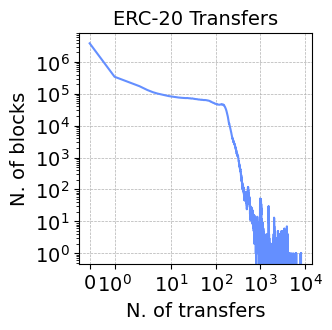

In [8]:
domain = np.arange(0, np.max(block_stats.numTransfer) + 1)
data = block_stats.numTransfer.value_counts().reindex(domain, fill_value=0)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of blocks')
ax.set_xscale('symlog')
ax.set_yscale('log')
ax.plot(data.index.values, data.values, color='#648fff')
ax.grid(linestyle='--', linewidth=0.5)
#ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)
plt.savefig("figures/ft_dist_transfers_block.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
domain = np.arange(0, np.max(block_stats.numTransfer) + 1)
data = block_stats.numTransfer.value_counts().reindex(domain, fill_value=0)
np.savetxt(f'tmp/block_transfers.out', data.values, fmt="%.6f", delimiter='\n')
p = subprocess.run(['./igraph/pl_fit', f'tmp/block_transfers.out'], capture_output=True)
p_out = p.stdout.decode('utf-8').rstrip()
a, xmin, l, d = np.float_(p_out.split('\t'))

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('N. of transfers')
ax.set_ylabel('N. of blocks')
ax.set_xscale('symlog')
ax.set_yscale('log')

x = np.arange(xmin, np.max(block_stats.numTransfer) + 1)
y = (data[xmin]/(xmin**(-a))) * (x**(-a))
ax.scatter(data.index.values, data.values, color='#dc267f', marker='.')
ax.plot(x, y, color='black')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)
#plt.savefig("figures/nft_dist_transfers_block.pdf", format='pdf', bbox_inches='tight')
plt.show()
print(a, xmin, l, d)

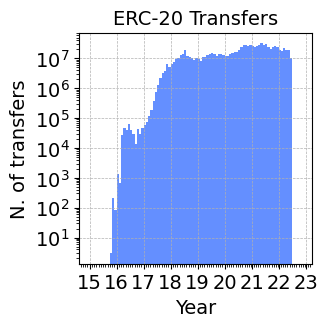

In [15]:
d1 = pd.to_datetime(block_stats.timestamp).astype(np.int64).values
d2 = block_stats.numTransfer.values
histBins = [pd.Timestamp(y, m, 1).timestamp() for y in range(2015, 2023, 1) for m in range(1, 12+1, 1)]
plotBins = [datetime.datetime(y, m, 1) for y in range(2015, 2023, 1) for m in range(1, 12+1, 1)]
s = stats.binned_statistic(d1, d2, statistic='sum', bins=histBins)

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot()
ax.set_title('ERC-20 Transfers')
ax.set_xlabel('Year')
ax.set_ylabel('N. of transfers')
ax.set_yscale('log')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(AutoMinorLocator(12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.stairs(s.statistic[:-1], plotBins[:-1], color='#648fff', fill=True)
ax.grid(linestyle='--', linewidth=0.5)
set_font_size(ax, 14)
plt.savefig("figures/ft_temporal_total_transfers.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Contract selection

We select the top 100 ERC-20 contracts based on the number of triggered Transfer events.<br>
<!--We do not consider transfers directed to the null address (i.e., 0x0...0) or originating from this address.-->

In [20]:
rank = pd.read_csv('results/ft/ranking/ft_ranking_nofilter.csv', header=None, names=['contractId', 'numTransfer'])
contractAddresses = pd.read_csv('data/ft/erc20_contracts.csv', header=None, names=['contractAddress', 'contractId'])
rank = rank.merge(contractAddresses, on=['contractId'], how='left')
rank = rank[['contractId', 'contractAddress', 'numTransfer']]
rank = rank.sort_values(by=['numTransfer'], ascending=False).head(100)
rank

,contractId,contractAddress,numTransfer
238900,12071,dac17f958d2ee523a2206206994597c13d831ec7,149408698
285489,13532,c02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,104183120
245407,65331,a0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,42601224
298885,124573,6b175474e89094c44da98b954eedeac495271d0f,14387573
331376,6423,514910771af9ca656af840dff83e8264ecf986ca,11388177
...,...,...,...
52812,37663,6c6ee5e31d828de241282b9606c8e98ea48526e2,885261
237677,3486,41e5560054824ea6b0732e656e3ad64e20e94e45,878794
12368,98833,7c5cb1220bd293ff9cf903915732e51a71292038,873211
66459,151770,57ab1ec28d129707052df4df418d58a2d46d5f51,870534


In [3]:
np.savetxt('results/ft/ranking/ft_top_addresses_nofilter.txt', rank.contractAddress.values, delimiter='\n', fmt='%s')

## Graph construction

We import the TSV file summarizing the properties of all 100 token networks. For each network we recorded the following information:

1. Number of nodes.
2. Number of edges.
3. Number of weakly connected components.
4. Time elapsed for the construction of the graph.

In [2]:
df = pd.read_csv('results/ft/ft_analyze_full.tsv', sep='\t')
df

,contract_id,num_nodes,num_edges,num_wcc,elapsed_time
0,0,23176194,66749187,170,66062277276
1,1,1121371,4648079,15475,3577420306
2,2,8235862,18006639,68,16797737961
3,3,1749966,4035204,873,3231046410
4,4,2374302,4198235,33,3769279289
...,...,...,...,...,...
95,95,295712,468557,36,289197348
96,96,277705,445533,2,274879858
97,97,431525,762013,1,390894389
98,98,42397,103577,145,56246626


We print the average number of nodes and edges among all 100 token networks.

In [3]:
print(f'Avg. nodes: {np.mean(df.num_nodes)}\nAvg. edges: {np.mean(df.num_edges)}')

Avg. nodes: 759003.99
Avg. edges: 1701879.33


We then plot the cumulative distribution functions for the number of nodes and number of edges across all 100 graphs.

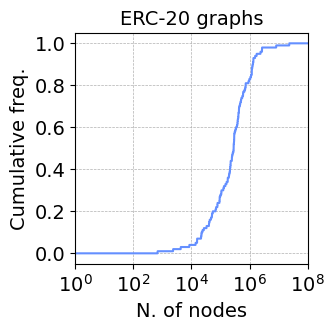

In [4]:
sizes = df.num_nodes.values
hist, bins = np.histogram(sizes, bins = np.arange(0, 1e8+1, 10))
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 graphs')
ax.set_xlabel('N. of nodes')
ax.set_ylabel('Cumulative freq.')
ax.set_xscale('log')
ax.plot(bins[:-1], np.cumsum(hist)/np.sum(hist), color='#648fff')
ax.grid(linestyle='--', linewidth=0.5)
ax.set_xlim(1, 1e8)
set_font_size(ax, 14)
plt.savefig("figures/ft_cumulative_nodes.pdf", format='pdf', bbox_inches='tight')
plt.show()

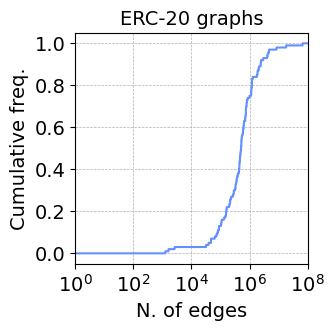

In [5]:
sizes = df.num_edges.values
hist, bins = np.histogram(sizes, bins = np.arange(0, 1e8+1, 10))
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 graphs')
ax.set_xlabel('N. of edges')
ax.set_ylabel('Cumulative freq.')
ax.set_xscale('log')
ax.set_xlim(1, 1e8)
ax.plot(bins[:-1], np.cumsum(hist)/np.sum(hist), color='#648fff')
ax.grid(linestyle='--', linewidth=0.5)
set_font_size(ax, 14)
plt.savefig("figures/ft_cumulative_edges.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Graph analysis

Let $G$ be a token network and $G_{LCC}$ be the subgraph induced by the nodes and edges of its largest connected component.

We associate each $G$ with 5 numerical features, namely:

1. Coverage, namely the percentage of nodes of $G$ included in $G_{LCC}$.
2. Relative diameter, which represents the ratio between the diameter of $G_{LCC}$ and the natural logarithm of the number of nodes.
3. Relative average shortest path length, which is computed as the average shortest path length of $G_{LCC}$ divided by the natural logarithm of the number of nodes.
4. Transitivity coincides with the global clustering coefficient of $G_{LCC}$, namely the ratio between the number of triangles and connected triples in the graph.
5. Density, as the ratio between the actual number of edges and the maximum possible number of edges in $G_{LCC}$.

We also associate to each network a categorical label describing the application domain of the corresponding contract.

In [38]:
features = final.columns[4:].values # List of features used for clustering
final = pd.read_csv('results/ft/ft_final.csv')
final

,contract_id,category,category_id,comp_nodes,coverage,diameter,est_apl,transitivity,density
0,0,defi,0,23175878,0.999986,2.948353,0.218610,0.000015,2.485440e-07
1,1,defi,0,1093419,0.975073,2.085608,0.274730,0.006812,7.754500e-06
2,2,defi,0,8235742,0.999985,3.893496,0.255894,0.000015,5.309530e-07
3,3,defi,0,1747934,0.998839,2.226250,0.287544,0.000093,2.640710e-06
4,4,other,1,2374247,0.999977,1.634856,0.299280,0.000019,1.489510e-06
...,...,...,...,...,...,...,...,...,...
95,95,other,1,295637,0.999746,1.587694,0.295035,0.000073,1.072110e-05
96,96,other,1,277703,0.999993,1.994526,0.309367,0.000046,1.155450e-05
97,97,storage,7,431525,1.000000,0.308283,0.193321,0.000015,8.184300e-06
98,98,defi,0,42109,0.993207,5.822681,0.305624,0.000562,1.166670e-04


In [39]:
final[features].mean().round(6)

coverage        0.981182
diameter        1.553374
est_apl         0.274752
transitivity    0.000355
density         0.000207
dtype: float64

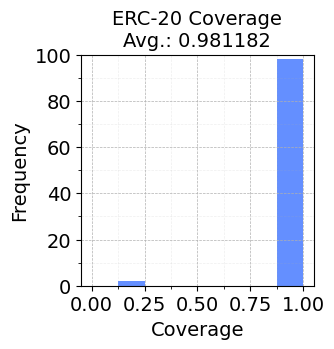

In [4]:
data = final['coverage']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Coverage\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Coverage')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 1.0+0.125, step=0.125), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 100)
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_coverage_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

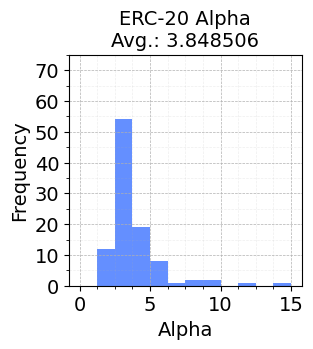

In [5]:
data = final['alpha']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Alpha\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Alpha')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 15.0+1.25, step=1.25), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 75)
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_alpha_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

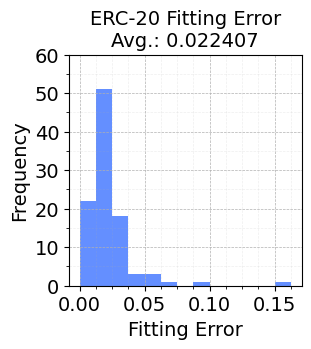

In [6]:
data = final['error']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Fitting Error\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Fitting Error')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0.0, 0.155+0.0125, step=0.0125), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 60)
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_error_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

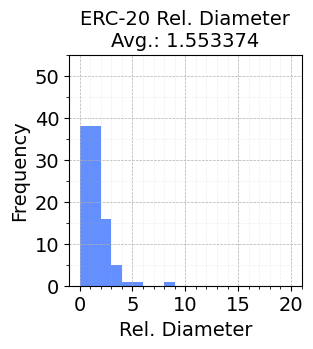

In [7]:
data = final['diameter']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Rel. Diameter\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Diameter')
ax.set_ylabel('Frequency')
plt.hist(data, bins=np.arange(0, 20+1), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 55)
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_diameter_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

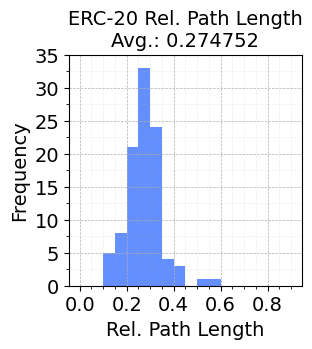

In [8]:
data = final['est_apl']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Rel. Path Length\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Rel. Path Length')
ax.set_ylabel('Frequency')
ax.hist(data, bins=np.arange(0, 95, 5) / 100, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(0, 35)
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_apl_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

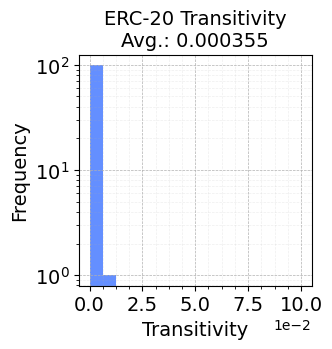

In [9]:
data = final['transitivity']
hist_bins = np.arange(0, 0.1 + 0.00625, step=0.00625)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Transitivity\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Transitivity')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=hist_bins, color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,-2))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_transitivity_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

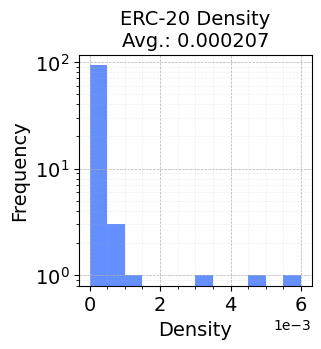

In [10]:
data = final['density']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 Density\nAvg.: {:.6f}'.format(np.mean(data)))
ax.set_xlabel('Density')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.hist(data, bins=np.arange(0, 0.006 + 0.0005, step=0.0005), color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3,-3))
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
set_font_size(ax, 14)
plt.savefig("figures/ft_feature_density_dist.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Clustering

In [49]:
kmeans_results = pd.read_csv('results/ft/ft_kmeans.csv')
kmeans_results

,features,k,silhouette,homogeneity
0,coverage,2,0.945020,0.019125
1,coverage,3,0.936985,0.045896
2,coverage,4,0.919398,0.063349
3,coverage,5,0.915467,0.063349
4,coverage,6,0.904284,0.063349
...,...,...,...,...
584,coverage diameter est_apl transitivity density,16,0.303857,0.329305
585,coverage diameter est_apl transitivity density,17,0.300941,0.319830
586,coverage diameter est_apl transitivity density,18,0.288219,0.331848
587,coverage diameter est_apl transitivity density,19,0.290629,0.357872


In [4]:
def plot_clustering(features, k, filename = None):
    features_str = ' '.join(features)
    clust_data = PowerTransformer().fit_transform(final[features])
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(clust_data)
    sil = silhouette_score(clust_data, pred_labels)
    result = pd.DataFrame(clust_data).assign(label = pred_labels)
    plt.figure(figsize=(3, 3))
    plt.title(f'Features: [{features_str}]\nSilhouette: {round(sil, 6)}')
    sns.countplot(x='label', color='#648fff', data=result)
    plt.xlabel('Cluster ID')
    plt.ylabel('N. of contracts')
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    plt.minorticks_on()
    plt.ylim(top=105)
    set_font_size(plt.gca(), 14)
    if (not (filename is None)):
        plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

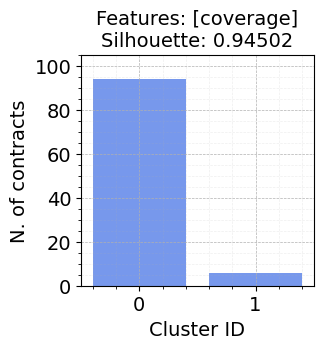

In [7]:
plot_clustering(['coverage'], 2, 'figures/ft_kmeans_top_1.pdf')

### PCA

We conduct further analysis based on dimensionality reduction. In particular:

1. We use principal component analysis to reduce the number of features.
2. We execute the K-means algorithm on this reduced data set.

Before applying the dimensionality reduction we use the _explained variance ratio_ method to determine the optimal number of components.

In [50]:
features

array(['coverage', 'diameter', 'est_apl', 'transitivity', 'density'],
      dtype=object)

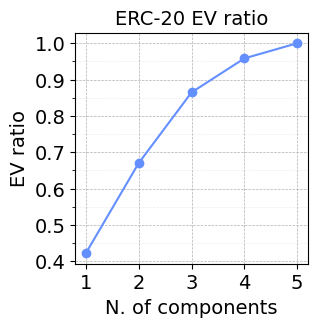

In [53]:
data = StandardScaler().fit_transform(final[features])
pca = PCA()
pca.fit(data)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 EV ratio')
ax.set_xlabel('N. of components')
ax.set_ylabel('EV ratio')
ax.plot(range(1, 6), pca.explained_variance_ratio_.cumsum(), marker='o', color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)

plt.savefig('figures/ft_pca_explained_variance.pdf', format='pdf', bbox_inches='tight')
plt.show()

We select $n=3$ as the optimal number of components (preserving at least 80\% of the orginal variance) and then execute K-means for different values of $k$ (i.e., ranging from 2 to 20, included). Below, we print the silhouette scores obtained for different values of $k$.

In [54]:
data = StandardScaler().fit_transform(final[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmin = 2
kmax = 20
sil = []
for k in np.arange(kmin, kmax+1):
    kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
    pred_labels = kmeans.fit_predict(X)
    sil.append(silhouette_score(X, pred_labels))
result = pd.DataFrame({'k' : np.arange(kmin, kmax+1), 'silhouette' : sil})
result

,k,silhouette
0,2,0.800502
1,3,0.757853
2,4,0.482679
3,5,0.456562
4,6,0.457263
5,7,0.476612
6,8,0.449061
7,9,0.443787
8,10,0.420472
9,11,0.380844


Then we plot the silhouette scores obtained for different values of $k$.

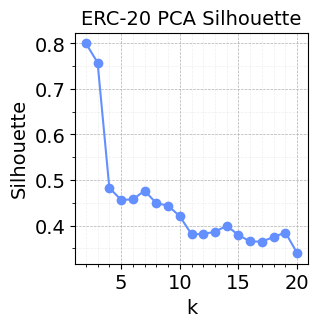

In [56]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('ERC-20 PCA Silhouette')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette')
ax.plot(result.k, result.silhouette, marker='o', color='#648fff')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
set_font_size(ax, 14)

plt.savefig('figures/ft_pca_silhouette.pdf', format='pdf', bbox_inches='tight')
plt.show()

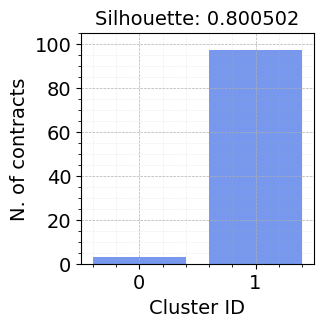

In [58]:
data = StandardScaler().fit_transform(final[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=2, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
result = pd.DataFrame(X).assign(label = pred_labels)#.assign(category = final.category)
plt.figure(figsize=(3, 3))
plt.title(f'Silhouette: {round(sil, 6)}')
sns.countplot(x='label', color='#648fff', data=result)
plt.xlabel('Cluster ID')
plt.ylabel('N. of contracts')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.minorticks_on()
plt.ylim(top=105)
set_font_size(plt.gca(), 14)
plt.savefig('figures/ft_pca_clustering.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [60]:
result.label.value_counts()

label
1    97
0     3
Name: count, dtype: int64

### Categorization

We manually assign to each contract (i.e., each network) a categorical label describing its main application domain.

1. defi comprises all tokens related to decentralized finance (e.g., stablecoins, wrapped tokens, tokens issued by exchanges and automated market makers, etc.);
2. gaming includes all token related to games; 
3. blockchain denotes all tokens related to independent blockchain projects; 
4. layer-2 contains tokens related to layer-2 solutions aimed at improving the scalability of Ethereum; 
5. content includes reward tokens related to content creation platforms; 
6. storage represents all tokens related to decentralized storage solutions; 
7. mining indicates tokens associated with cryptocurrency mining services; 
8. multimedia comprises all tokens related to multimedia content (e.g., music, video streaming services, etc.); 
9. other comprises all tokens whose application domain is not included into any of the previous categories.

In [61]:
final = pd.read_csv('results/ft/ft_final.csv')
#final.category = final.category.replace('games', 'gaming')
final

,contract_id,category,category_id,comp_nodes,coverage,diameter,est_apl,transitivity,density
0,0,defi,0,23175878,0.999986,2.948353,0.218610,0.000015,2.485440e-07
1,1,defi,0,1093419,0.975073,2.085608,0.274730,0.006812,7.754500e-06
2,2,defi,0,8235742,0.999985,3.893496,0.255894,0.000015,5.309530e-07
3,3,defi,0,1747934,0.998839,2.226250,0.287544,0.000093,2.640710e-06
4,4,other,1,2374247,0.999977,1.634856,0.299280,0.000019,1.489510e-06
...,...,...,...,...,...,...,...,...,...
95,95,other,1,295637,0.999746,1.587694,0.295035,0.000073,1.072110e-05
96,96,other,1,277703,0.999993,1.994526,0.309367,0.000046,1.155450e-05
97,97,storage,7,431525,1.000000,0.308283,0.193321,0.000015,8.184300e-06
98,98,defi,0,42109,0.993207,5.822681,0.305624,0.000562,1.166670e-04


In [64]:
final.category.value_counts()

category
defi          54
other         15
gaming         9
blockchain     5
layer-2        4
content        4
storage        4
mining         3
multimedia     2
Name: count, dtype: int64

In [65]:
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
cmap = LinearSegmentedColormap.from_list('my_cmap', colors)
categories = final.category_id.values
#labels=['blockchain','content','defi','games','layer-2','mining','multimedia','other','storage']

We print the details about the configurations with $k=8$ yielding the highest silhouette and homogeneity scores.

In [77]:
conf = kmeans_results[kmeans_results.k == 8]
print(conf.iloc[np.argmax(conf.silhouette)])
print("")
print(conf.iloc[np.argmax(conf.homogeneity)])

features       coverage
k                     8
silhouette     0.899257
homogeneity    0.092461
Name: 6, dtype: object

features       coverage diameter est_apl
k                                      8
silhouette                      0.349785
homogeneity                     0.235004
Name: 291, dtype: object


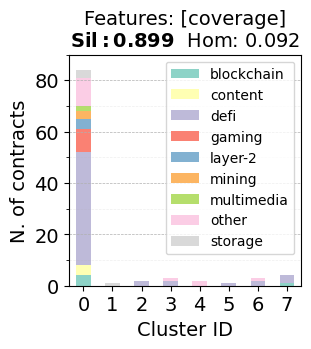

In [74]:
features = ['coverage']
k = 8
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(final[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pd.DataFrame(clust_data).assign(label = pred_labels).assign(category = final.category.values)
xt = pd.crosstab(result.label, result.category)

fig, ax = plt.subplots(figsize=(3, 3))
xt.plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(f'Features: [{features_str}]\n' + r'$\bf{Sil: {' + str(round(sil, 3)) + r'}}$' + f'  Hom: {round(hom, 3)}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.set_ylim(top=90)
ax.legend(loc='upper right')
set_font_size(ax, 14)
plt.savefig('figures/ft_hom_1.pdf', format='pdf', bbox_inches='tight')
plt.show()

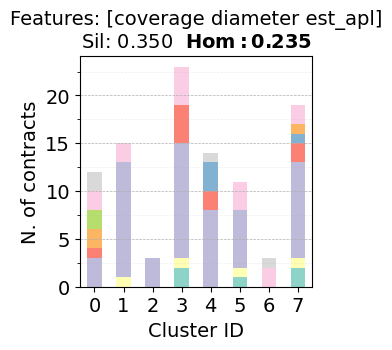

In [75]:
features = ['coverage', 'diameter', 'est_apl']
k = 8
features_str = ' '.join(features)
clust_data = PowerTransformer().fit_transform(final[features])
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(clust_data)
sil = silhouette_score(clust_data, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pd.DataFrame(clust_data).assign(label = pred_labels).assign(category = final.category.values)
xt = pd.crosstab(result.label, result.category)

fig, ax = plt.subplots(figsize=(3, 3))
xt.plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(f'Features: [{features_str}]\n' + 'Sil: {:.3f}  '.format(sil) + r'$\bf{Hom: {' + str(round(hom,3)) + r'}}$')
#+ r'$\bf{Sil: {' + str(round(sil, 3)) + r'}}$' + f'  Hom: {round(hom, 3)}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
#ax.set_ylim(top=50)
#ax.legend(loc='upper right')
set_font_size(ax, 14)
plt.savefig('figures/ft_hom_2.pdf', format='pdf', bbox_inches='tight')
plt.show()

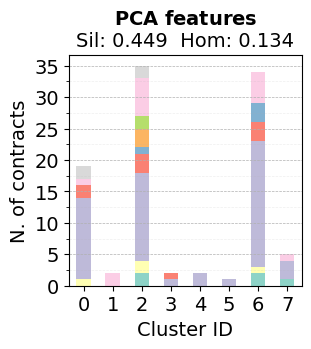

In [76]:
features = ['coverage', 'diameter', 'est_apl', 'transitivity', 'density']
k = 8
data = StandardScaler().fit_transform(final[features])
pca = PCA(n_components=3)
X = pca.fit_transform(data)
kmeans = KMeans(init='k-means++', n_clusters=k, n_init=100, max_iter=1000, random_state=1)
pred_labels = kmeans.fit_predict(X)
sil = silhouette_score(X, pred_labels)
hom = homogeneity_score(categories, pred_labels)
result = pd.DataFrame(data).assign(label = pred_labels).assign(category = final.category.values)
xt = pd.crosstab(result.label, result.category)

fig, ax = plt.subplots(figsize=(3, 3))
xt.plot(kind='bar', stacked=True, ax = ax, cmap=cmap, legend=False)
ax.set_title(r"$\bf{PCA\ features}$" + f"\nSil: {round(sil, 3)}  Hom: {round(hom, 3)}")
ax.set_xlabel('Cluster ID')
ax.set_ylabel('N. of contracts')
ax.set_xticklabels(ax.get_xticks(), rotation = 0)
ax.yaxis.grid(which='major', linestyle='--', linewidth=0.5)
ax.yaxis.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
#ax.set_ylim(top=50)
set_font_size(ax, 14)
plt.savefig('figures/ft_hom_3.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Temporal analysis by category

In [8]:
block_timestamps = pd.read_csv('data/block_timestamps_0-14999999.csv', header=None, names=['blockId', 'timestamp'])
block_timestamps

,blockId,timestamp
0,0,1438269973
1,1,1438269988
2,2,1438270017
3,3,1438270048
4,4,1438270077
...,...,...
14999995,14999995,1655778452
14999996,14999996,1655778455
14999997,14999997,1655778471
14999998,14999998,1655778488


In [10]:
event_count = pd.read_csv('results/ft/ft_category_count.csv').rename(columns={'blockId_category':'blockId'})
event_count = event_count.set_index('blockId').reindex(np.arange(0, 15000000), fill_value=0).reset_index()
event_count = event_count.merge(block_timestamps, on='blockId', how='left')
event_count

,blockId,blockchain,content,defi,games,layer-2,mining,multimedia,other,storage,timestamp
0,0,0,0,0,0,0,0,0,0,0,1438269973
1,1,0,0,0,0,0,0,0,0,0,1438269988
2,2,0,0,0,0,0,0,0,0,0,1438270017
3,3,0,0,0,0,0,0,0,0,0,1438270048
4,4,0,0,0,0,0,0,0,0,0,1438270077
...,...,...,...,...,...,...,...,...,...,...,...
14999995,14999995,0,0,46,0,0,0,0,1,0,1655778452
14999996,14999996,1,1,46,1,1,0,0,1,0,1655778455
14999997,14999997,2,0,57,0,0,0,0,1,1,1655778471
14999998,14999998,0,0,10,1,1,0,0,0,0,1655778488


In [15]:
categories = np.setdiff1d(event_count.columns.values, ['blockId', 'timestamp'])
seconds_in_a_week = 60 * 60 * 24 * 7
start_date = np.int64(pd.Timestamp(2015, 1, 1).timestamp())
end_date = np.int64(pd.Timestamp(2023, 1, 1).timestamp())
hist_bins = np.arange(start_date, end_date + seconds_in_a_week, seconds_in_a_week)
timestamps = pd.to_datetime(event_count.timestamp).astype(np.int64).values

df_data = dict()
for cat in categories:
    bs = stats.binned_statistic(timestamps, event_count[cat].values, statistic='sum', bins=hist_bins)
    df_data[cat] = bs.statistic
df_data['timestamp'] = bs.bin_edges[:-1]

event_count_ext = pd.DataFrame(df_data).astype(int)
event_count_ext['sum'] = np.sum(event_count_ext[categories], axis=1)
for cat in categories:
    event_count_ext[cat + 'Perc'] = event_count_ext[cat] / event_count_ext['sum']
event_count_ext = event_count_ext.fillna(0)
event_count_ext = event_count_ext.rename(columns = {'games':'gaming', 'gamesPerc':'gamingPerc'})
event_count_ext

,blockchain,content,defi,gaming,layer-2,mining,multimedia,other,storage,timestamp,sum,blockchainPerc,contentPerc,defiPerc,gamingPerc,layer-2Perc,miningPerc,multimediaPerc,otherPerc,storagePerc
0,0,0,0,0,0,0,0,0,0,1420070400,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,1420675200,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,0,0,0,0,1421280000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,0,0,0,0,0,1421884800,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,0,0,0,0,0,1422489600,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0,0,0,0,0,0,0,0,0,1669852800,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
414,0,0,0,0,0,0,0,0,0,1670457600,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
415,0,0,0,0,0,0,0,0,0,1671062400,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
416,0,0,0,0,0,0,0,0,0,1671667200,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


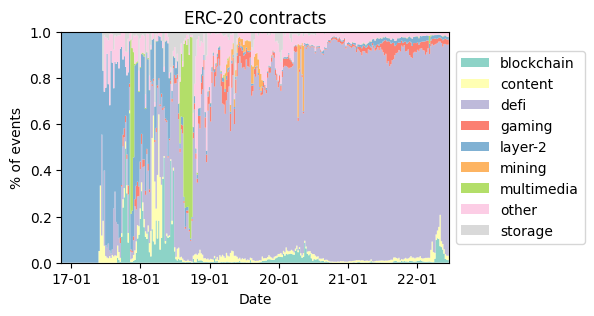

In [16]:
x = event_count_ext[event_count_ext['sum'] > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')

fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(dates, 
              x['blockchainPerc'], 
              x['contentPerc'], 
              x['defiPerc'], 
              x['gamingPerc'], 
              x['layer-2Perc'], 
              x['miningPerc'],
              x['multimediaPerc'],
              x['otherPerc'],
              x['storagePerc'],
             colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9'],
             labels=['blockchain','content','defi','gaming','layer-2','mining','multimedia','other','storage'], 
             step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.savefig("figures/ft_events_category.pdf", format='pdf', bbox_inches='tight')
plt.show()

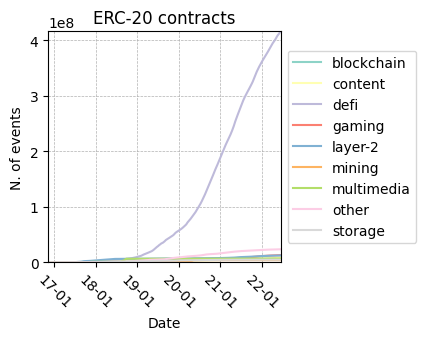

In [17]:
x = event_count_ext[event_count_ext['sum'] > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
labels=['blockchain','content','defi','gaming','layer-2','mining','multimedia','other','storage']

fig = plt.figure(figsize=(3, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
for i in range(0, len(labels)):
    ax1.plot(dates, np.cumsum(x[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig("figures/ft_events_category_cumulative_1.pdf", format='pdf', bbox_inches='tight')
plt.show()

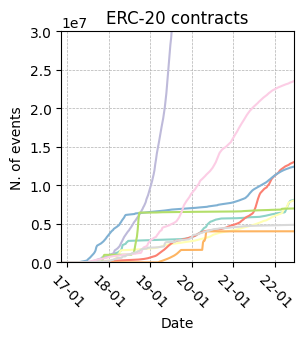

In [26]:
x = event_count_ext[event_count_ext['sum'] > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
labels=['blockchain','content','defi','games','layer-2','mining','multimedia','other','storage']

fig = plt.figure(figsize=(3, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
for i in range(0, len(labels)):
    ax1.plot(dates, np.cumsum(x[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)
#ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.set_ylim(0, (0.3*1e8))

plt.savefig("figures/ft_events_category_cumulative_2.pdf", format='pdf', bbox_inches='tight')
plt.show()

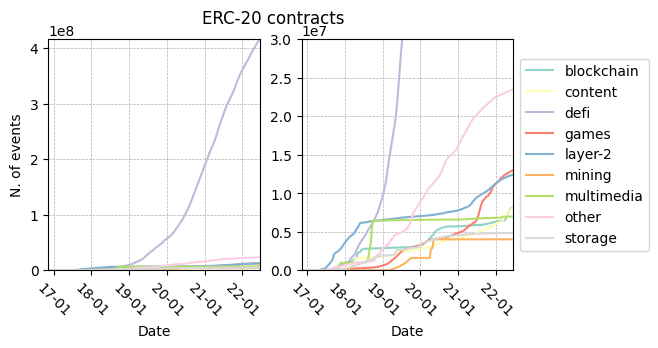

In [18]:
x = event_count_ext[event_count_ext['sum'] > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')
colors=['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']
labels=['blockchain','content','defi','games','layer-2','mining','multimedia','other','storage']

#fig = plt.figure(figsize=(3, 3))
#ax1 = fig.add_subplot()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), sharex=False, sharey=False)
fig.suptitle('ERC-20 contracts')

ax1.set_xlabel('Date')
ax1.set_ylabel('N. of events')
#ax1.set_yscale('log')
for i in range(0, len(labels)):
    ax1.plot(dates, np.cumsum(x[labels[i]]), color=colors[i], label=labels[i])
ax1.margins(0,0)
ax1.grid(which='major', linestyle='--', linewidth=0.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax1.tick_params(axis='x', labelrotation=-45)

ax2.set_xlabel('Date')
for i in range(0, len(labels)):
    ax2.plot(dates, np.cumsum(x[labels[i]]), color=colors[i], label=labels[i])
ax2.margins(0,0)
ax2.grid(which='major', linestyle='--', linewidth=0.5)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax2.tick_params(axis='x', labelrotation=-45)
ax2.set_ylim(0, (0.3*1e8))

#t = [0, 1*1e8, 2*1e8]
#ax1.set_yticks([])#range(len(t)), t)#set_ylim(0, (0.3*1e8))

plt.savefig("figures/ft_events_category_cumulative.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Top 3 contracts

In [9]:
contract_count = pd.read_csv('results/ft/ft_top_count.csv').rename(columns={'blockId_contractId':'blockId'})
contract_count = contract_count.set_index('blockId').reindex(np.arange(0, 15000000), fill_value=0).reset_index()
contract_count['timestamp'] = block_timestamps['timestamp']
contract_count

,blockId,10188,103539,105002,106324,109026,111591,112388,112965,113404,...,77616,80892,82641,85096,92578,9596,96617,98804,98833,timestamp
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438269973
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438269988
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438270017
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438270048
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1438270077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999995,14999995,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,1655778452
14999996,14999996,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1655778455
14999997,14999997,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,1655778471
14999998,14999998,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1655778488


In [10]:
contract_ids = np.setdiff1d(contract_count.columns.values, ['blockId', 'timestamp'])
seconds_in_a_week = 60 * 60 * 24 * 7
start_date = np.int64(pd.Timestamp(2015, 1, 1).timestamp())
end_date = np.int64(pd.Timestamp(2023, 1, 1).timestamp())
hist_bins = np.arange(start_date, end_date + seconds_in_a_week, seconds_in_a_week)
timestamps = pd.to_datetime(contract_count.timestamp).astype(np.int64).values

df_data = dict()
bs = None
for i in contract_ids:
    bs = stats.binned_statistic(timestamps, contract_count[i].values, statistic='sum', bins=hist_bins)
    df_data[i] = bs.statistic
df_data['timestamp'] = bs.bin_edges[:-1]

contract_count_ext = pd.DataFrame(df_data).astype(int)
total = np.sum(contract_count_ext[contract_ids], axis=1)
top_1 = np.max(contract_count_ext[contract_ids], axis=1)
top_2 = pd.Series(np.partition(contract_count_ext[contract_ids], -2, axis=1)[:, -2])
top_3 = pd.Series(np.partition(contract_count_ext[contract_ids], -3, axis=1)[:, -3])
others = total - (top_1 + top_2 + top_3)
ft = pd.DataFrame({'timestamp' : contract_count_ext.timestamp, 'top1' : top_1, 'top2' : top_2, 'top3' : top_3, 'remaining' : others, 'total' : total})
ft['top1Perc'] = ft['top1']/ft['total']
ft['top2Perc'] = ft['top2']/ft['total']
ft['top3Perc'] = ft['top3']/ft['total']
ft['remainingPerc'] = ft['remaining']/ft['total']
ft = ft.fillna(0)
ft

,timestamp,top1,top2,top3,remaining,total,top1Perc,top2Perc,top3Perc,remainingPerc
0,1420070400,0,0,0,0,0,0.0,0.0,0.0,0.0
1,1420675200,0,0,0,0,0,0.0,0.0,0.0,0.0
2,1421280000,0,0,0,0,0,0.0,0.0,0.0,0.0
3,1421884800,0,0,0,0,0,0.0,0.0,0.0,0.0
4,1422489600,0,0,0,0,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
413,1669852800,0,0,0,0,0,0.0,0.0,0.0,0.0
414,1670457600,0,0,0,0,0,0.0,0.0,0.0,0.0
415,1671062400,0,0,0,0,0,0.0,0.0,0.0,0.0
416,1671667200,0,0,0,0,0,0.0,0.0,0.0,0.0


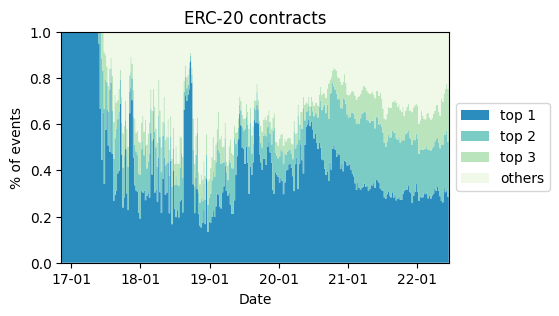

In [11]:
x = ft[ft.total > 0]
dates = x.timestamp.astype(dtype='datetime64[s]')

fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot()
ax1.set_title('ERC-20 contracts')
ax1.set_xlabel('Date')
ax1.set_ylabel('% of events')
ax1.stackplot(dates, x['top1Perc'], x['top2Perc'], x['top3Perc'], x['remainingPerc'],
            colors=['#2b8cbe', '#7bccc4', '#bae4bc', '#f0f9e8'],
            labels=['top 1', 'top 2', 'top 3', 'others'], 
            step='post')
ax1.margins(0,0)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.savefig("figures/ft_events_top.pdf", format='pdf', bbox_inches='tight')
plt.show()